正在运行 Grid Search 以获取基准曲线 (Vector RLS)...
Grid Search 完成。
N=31 Baseline 最优 Sigma: 1.1000

正在运行 Scalar Adaptive EKF (N=31)...
Adaptive EKF 完成。稳态平均 MSE: 0.0963
Sigma 收敛至: 1.0129


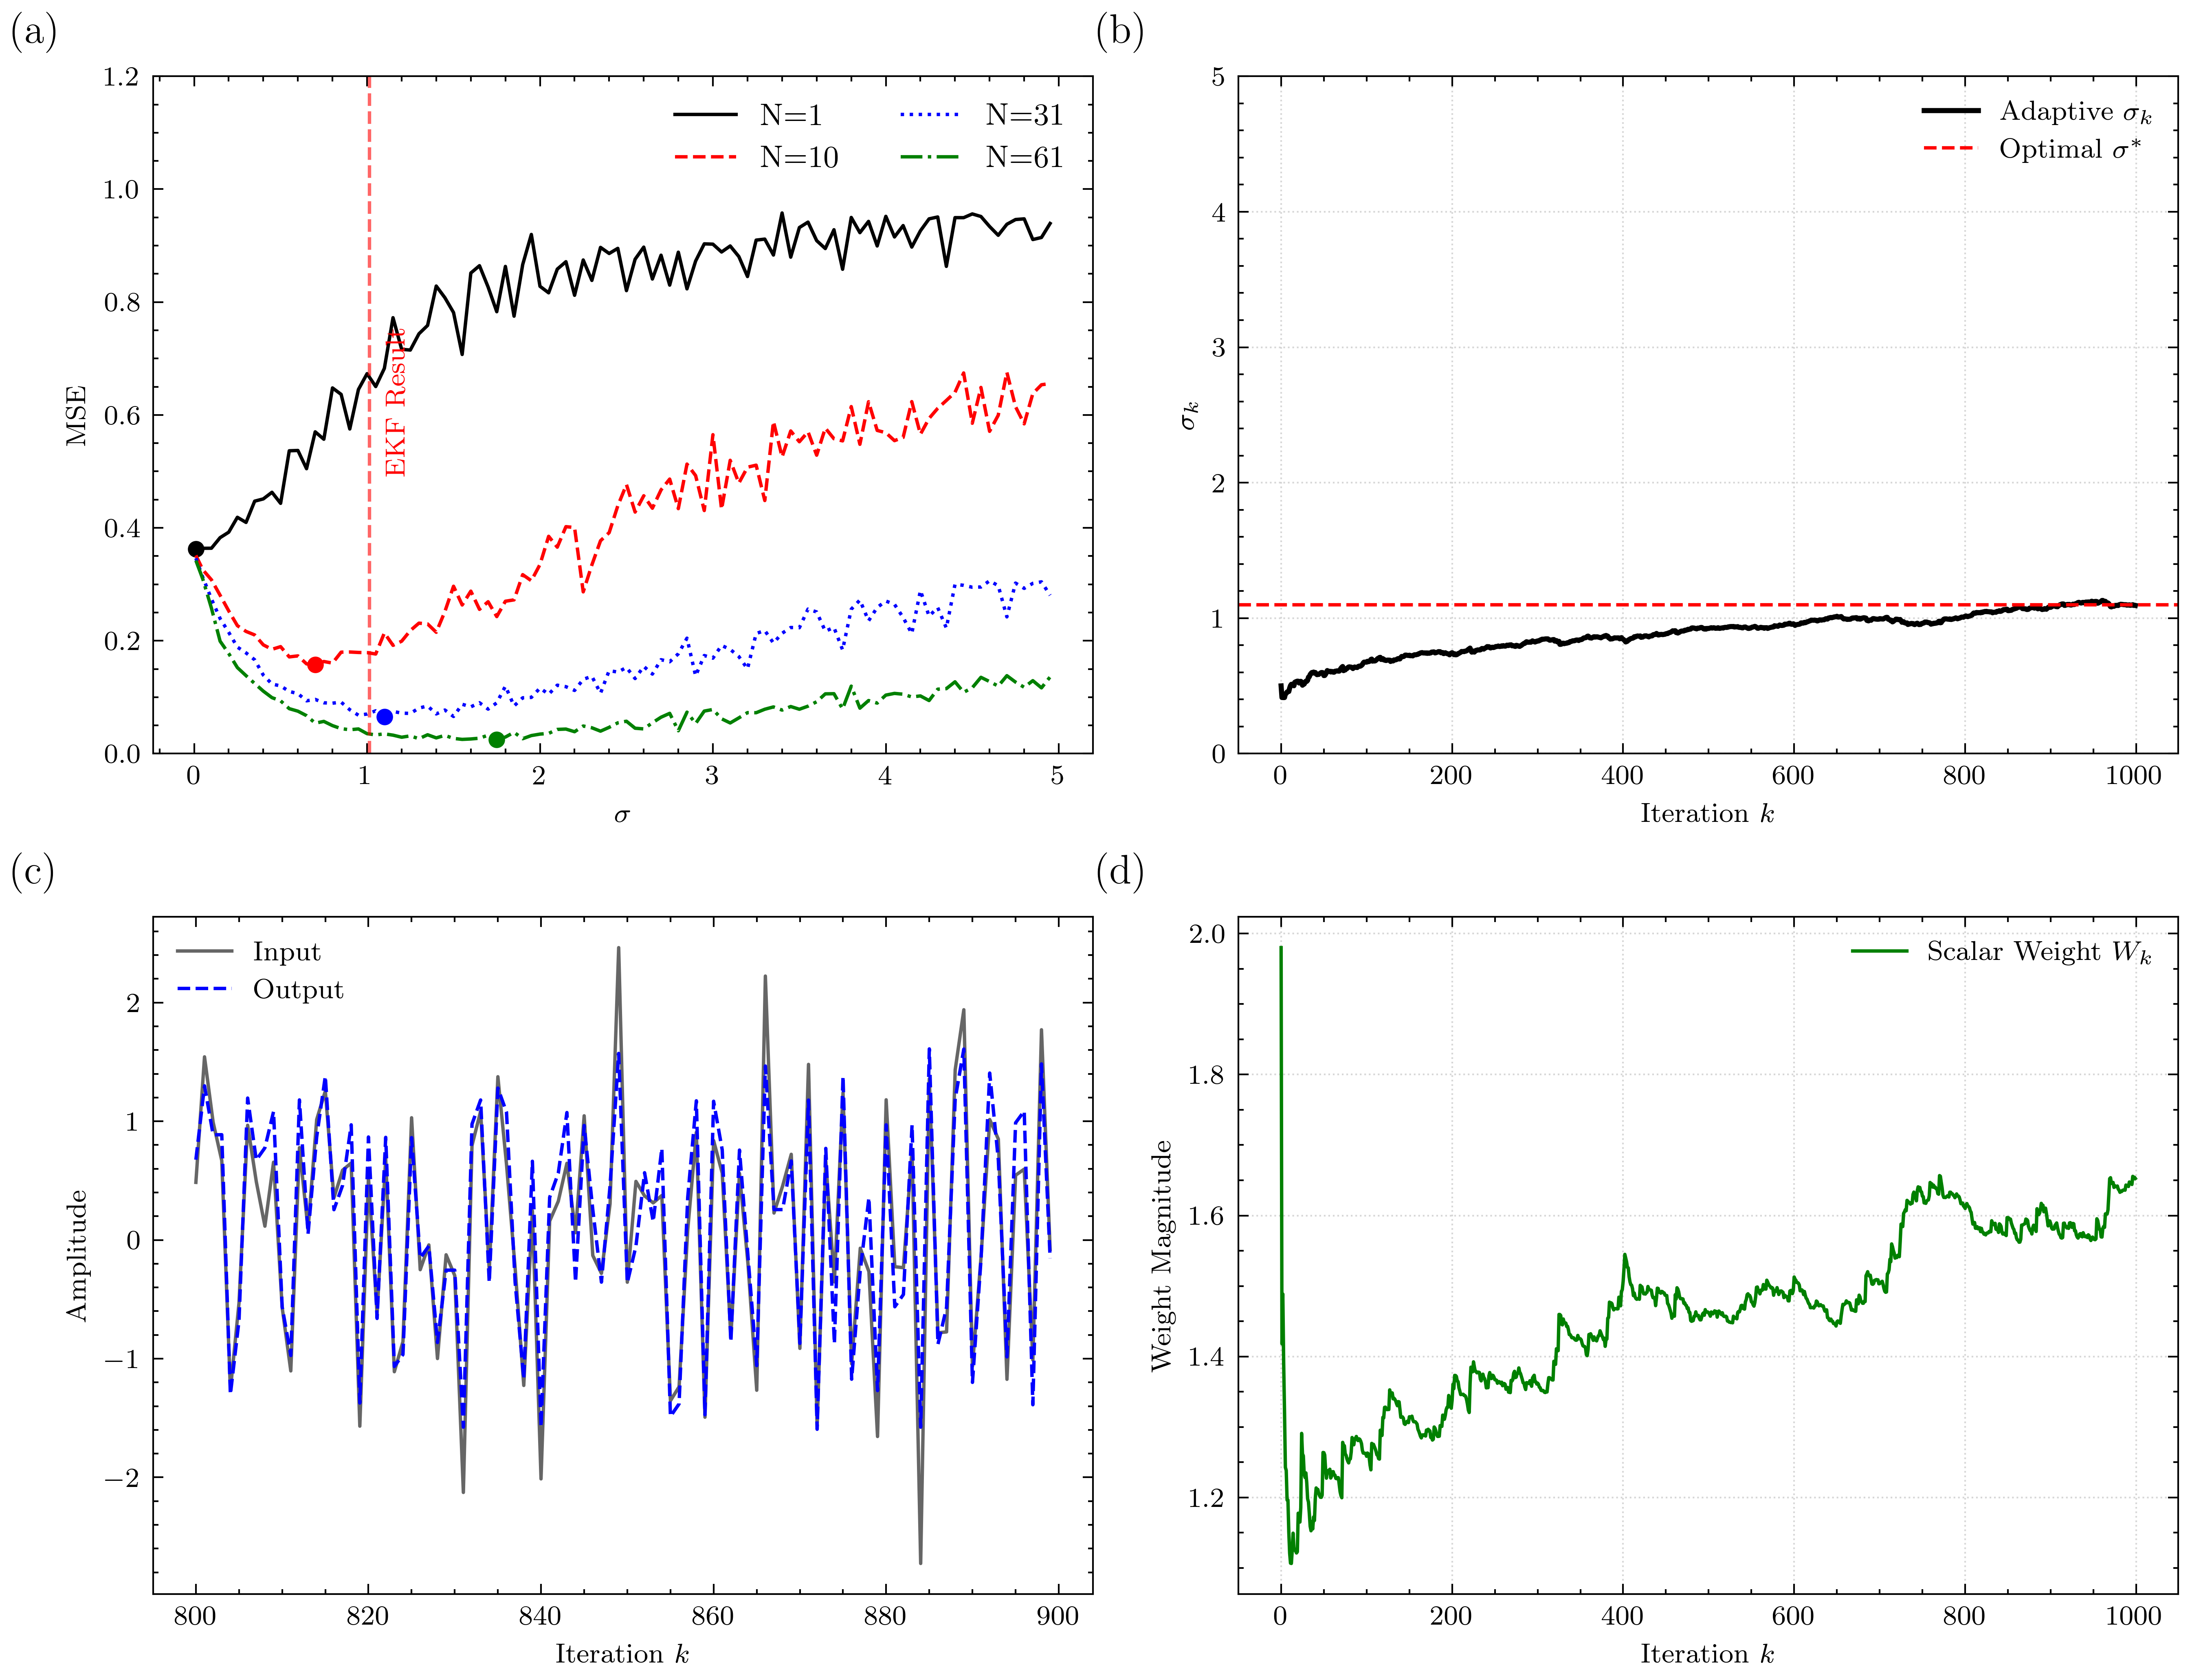

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots 

# --- 绘图风格设置 ---
try:
    plt.style.use(['science', 'ieee'])
except:
    plt.style.use('default')
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['axes.unicode_minus'] = False

# --- 基础函数定义 ---
def gaussian_pdf(x):
    """标准高斯分布概率密度函数"""
    return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)

# 设置随机种子 (严格保持不变)
seed_val = 451
torch.manual_seed(seed_val)
np.random.seed(seed_val)

# --- 全局参数 ---
Nx_total = 1000  
input_data = torch.randn(Nx_total, 1) # x_k

# ==========================================
# 第一部分：Grid Search (基准) - 【完全恢复原代码】
# ==========================================
# 注意：为了节省时间且Grid只是参考，我们只用前200个点跑Grid
Nx_grid = 200
print("正在运行 Grid Search 以获取基准曲线 (Vector RLS)...")
S_grid = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
N_values_grid = [1, 2, 10, 31, 61]
results_grid = {}

for N in N_values_grid:
    MSE_array = torch.zeros(len(S_grid))
    
    for i in range(len(S_grid)):
        # 初始化：这里为了公平，权重的“和”应该约为1
        w = torch.ones(N, 1) / N 
        P = torch.eye(N) * 10.0 # RLS初始P
        reg_param = 0.01
        
        Noise = S_grid[i] * torch.randn(Nx_grid, N)
        y_hat_hist = torch.zeros(Nx_grid)
        
        for k in range(Nx_grid):
            h_in = input_data[k, 0] + Noise[k, :]
            y = torch.sign(h_in).reshape(N, 1)
            
            # RLS (Vector Version)
            denom = y.T @ P @ y + reg_param
            g = (P @ y) / denom
            err = input_data[k, 0] - y.T @ w
            w = w + g * err
            P = P - g @ y.T @ P
            
            y_hat_hist[k] = (y.T @ w).item()
            
        MSE_array[i] = torch.mean((input_data[:Nx_grid, 0] - y_hat_hist)**2)
        
    min_mse, min_idx = torch.min(MSE_array, dim=0)
    results_grid[N] = {
        'S': S_grid,
        'MSE': MSE_array,
        'best_mse': min_mse,
        'best_S': S_grid[min_idx]
    }

print("Grid Search 完成。")
print(f"N=31 Baseline 最优 Sigma: {results_grid[31]['best_S']:.4f}")


# ==========================================
# 第二部分：Adaptive EKF + Scalar RLS (改造部分)
# ==========================================
print("\n正在运行 Scalar Adaptive EKF (N=31)...")

N_adapt = 31

# 【改造点 1】权重初始化为标量 (Scalar Weight)
# 我们不再维护 N 个权重，而是维护一个总增益 W_scalar
W_scalar = torch.tensor([[1.0]]) 
P_rls = torch.tensor([[10.0]])   # 标量 P
lambda_rls = 0.99 

# EKF 参数
sigma_curr = 0.5  # 初始劣质值
P_sigma = 0.1     # 初始方差
Q_sigma_base = 1e-4  # 基础过程噪声
R_sigma = 1.0     # 观测噪声
sigma_min = 0.03

sigma_history = torch.zeros(Nx_total)
y_hat_adpt = torch.zeros(Nx_total)
w_history = torch.zeros(Nx_total) # 记录标量权重

for k in range(Nx_total):
    x_k = input_data[k, 0]
    
    # 1. 物理过程 (产生观测)
    noise_vec = sigma_curr * torch.randn(N_adapt, 1) 
    y_vec = torch.sign(x_k + noise_vec) 
    
    # 【改造点 2】RLS 输入特征改为阵列平均值 (Scalar)
    phi_k = torch.mean(y_vec) 
    
    # 2. Scalar RLS 更新
    # 预测
    y_hat_k = W_scalar * phi_k
    e_k = x_k - y_hat_k 
    
    # RLS 公式 (标量)
    denom = phi_k**2 * P_rls + lambda_rls
    g_rls = (P_rls * phi_k) / denom
    
    W_scalar = W_scalar + g_rls * e_k
    P_rls = (P_rls - g_rls * phi_k * P_rls) / lambda_rls
    
    # 记录线性化点
    x_est = y_hat_k.item()
    
    # 3. EKF 更新 Sigma
    sigma_pred = sigma_curr 
    
    # 【改造点 3】Q_sigma 兜底机制 (防止死锁)
    Q_k = Q_sigma_base
    if sigma_pred < 0.1 or abs(x_est) < 0.1:
        Q_k = 1e-3 # 当梯度可能消失时，增大过程噪声
        
    P_sigma_pred = P_sigma + Q_k
    
    # 【改造点 4】Jacobian 计算 (标量版)
    # H = - 2 * W * (x / sigma^2) * f(x/sigma)
    s_safe = max(sigma_pred, 0.01) 
    u = x_est / s_safe
    pdf_val = gaussian_pdf(torch.tensor(u))
    
    H_k = - 2.0 * W_scalar.item() * (x_est / (s_safe**2)) * pdf_val.item()
    
    # 卡尔曼增益
    S_innov = H_k**2 * P_sigma_pred + R_sigma
    K_sigma = P_sigma_pred * H_k / S_innov
    
    # 更新状态
    sigma_new = sigma_pred + K_sigma * e_k.item()
    
    # 硬约束
    sigma_new = max(min(sigma_new, 8.0), sigma_min)
    
    # 更新协方差
    P_sigma = (1 - K_sigma * H_k) * P_sigma_pred
    
    # 记录
    sigma_history[k] = sigma_curr
    sigma_curr = sigma_new
    y_hat_adpt[k] = x_est
    w_history[k] = W_scalar.item()

# 计算稳态 MSE
steady_state_idx = 500
final_mse_adpt = torch.mean((input_data[steady_state_idx:, 0] - y_hat_adpt[steady_state_idx:])**2)
final_sigma_val = torch.mean(sigma_history[steady_state_idx:])

print(f"Adaptive EKF 完成。稳态平均 MSE: {final_mse_adpt:.4f}")
print(f"Sigma 收敛至: {final_sigma_val:.4f}")


# ==========================================
# 第三部分：绘图
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()
labels_txt = ['(a)', '(b)', '(c)', '(d)']

# --- (a) MSE Landscape ---
ax = axes[0]
for idx, N_val in enumerate([1, 10, 31, 61]):
    res = results_grid[N_val]
    ax.plot(res['S'], res['MSE'], label=f'N={N_val}')
    ax.scatter(res['best_S'], res['best_mse'], s=15)

ax.axvline(final_sigma_val, color='r', linestyle='--', alpha=0.6)
ax.text(final_sigma_val+0.1, 0.5, r'EKF Result', color='r', rotation=90)

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([0, 1.2])
ax.legend(fontsize=9, ncol=2)
ax.text(-0.15, 1.05, labels_txt[0], transform=ax.transAxes, fontsize=12, weight='bold')

# --- (b) Sigma Evolution ---
ax = axes[1]
plot_len = 1000
k_axis = np.arange(plot_len)
ax.plot(k_axis, sigma_history[:plot_len].numpy(), 'k-', linewidth=1.5, label=r'Adaptive $\sigma_k$')
ax.axhline(results_grid[31]['best_S'], color='r', linestyle='--', label=r'Optimal $\sigma^*$')

ax.set_xlabel('Iteration $k$')
ax.set_ylabel(r'$\sigma_k$')
ax.legend()
ax.set_ylim([0, 5.0])
ax.text(-0.15, 1.05, labels_txt[1], transform=ax.transAxes, fontsize=12, weight='bold')
ax.grid(True, linestyle=':', alpha=0.5)

# --- (c) Tracking ---
ax = axes[2]
start_k = 800
end_k = 900
ax.plot(np.arange(start_k, end_k), input_data[start_k:end_k].numpy(), 'k-', alpha=0.6, label='Input')
ax.plot(np.arange(start_k, end_k), y_hat_adpt[start_k:end_k].numpy(), 'b--', label='Output')
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('Amplitude')
ax.legend()
ax.text(-0.15, 1.05, labels_txt[2], transform=ax.transAxes, fontsize=12, weight='bold')

# --- (d) Scalar Weight ---
ax = axes[3]
ax.plot(k_axis, w_history[:plot_len].numpy(), 'g-', label=r'Scalar Weight $W_k$')
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('Weight Magnitude')
ax.legend(loc='upper right')
ax.text(-0.15, 1.05, labels_txt[3], transform=ax.transAxes, fontsize=12, weight='bold')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()